# Dirty Data Profiling

The dirty data profiling workflow uses **dbt as the source of truth for data quality** and converts dbt validation results into dataset level statistics, failure analysis, insights, dashboard metrics, and exportable results.

The reusable profiling logic lives in `dirty_data_profiling/`. This notebook **loads the generated profiling artifacts** and orchestrates their analysis and visualisation rather than re-running the profiling workflow.

## Configuration

In [35]:
from pathlib import Path
import os
import sys

PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebook":
    PROJECT_ROOT = PROJECT_ROOT.parent.parent

os.chdir(PROJECT_ROOT)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

SOURCE_DATASET = "synthetic_dirty"
DBT_TARGET = "dirty"
DATASET = None
OUTPUT_DIR = PROJECT_ROOT / "reports" / "profiling"

print(f"Project root : {PROJECT_ROOT}")
print(f"Source      : {SOURCE_DATASET}")
print(f"dbt target  : {DBT_TARGET}")
print(f"Dataset     : {DATASET or 'all'}")
print(f"Output      : {OUTPUT_DIR}")

Project root : /Users/jengazee/Documents/GitHub/MegaMart
Source      : synthetic_dirty
dbt target  : dirty
Dataset     : all
Output      : /Users/jengazee/Documents/GitHub/MegaMart/reports/profiling


## Imports

In [36]:
import pandas as pd
import matplotlib.pyplot as plt

from dirty_data_profiling.dbt.artifact_loader import DBTArtifactLoader

## Profiling Artifacts

In [37]:
summary = pd.read_csv(
    OUTPUT_DIR / "summary.csv"
)

dirty_records = pd.read_csv(
    OUTPUT_DIR / "dirty_records.csv",
    header=None,
    names=[
        "dataset",
        "record_key",
        "test_name",
        "test_description",
        "test_level",
        "category",
        "severity",
        "details",
]

)

if DATASET is not None:
    summary = summary.loc[
        summary["dataset"] == DATASET
    ].reset_index(drop=True)

    dirty_records = dirty_records.loc[
        dirty_records["dataset"] == DATASET
    ].reset_index(drop=True)

print(f"\nDatasets profiled : {summary['dataset'].nunique()}")
print(f"Summary rows      : {len(summary)}")
print(f"Dirty records     : {len(dirty_records)}")


Datasets profiled : 26
Summary rows      : 26
Dirty records     : 5569


## Overall Validation Summary

This section provides the dataset-level statistics generated by the profiling workflow.

- **Rows** — total records in the dataset.
- **Affected rows** — unique records associated with at least one failed validation rule.
- **Clean rows** — total rows minus affected rows.
- **Affected row rate** — proportion of records affected by one or more failed rules.
- **Failure instances** — total failed validation records across all failed rules.
- **Most affected column / rule / category** — highest failure count within the corresponding dimension.

In [38]:
display_summary = summary.copy()

if not display_summary.empty:
    display_summary["affected_row_rate"] = (
        display_summary["affected_row_rate"]
        .map(lambda x: f"{x:.2f}%")
    )

display(display_summary)

,dataset,rows,affected_rows,clean_rows,affected_row_rate,failure_instances,most_affected_column,most_failed_rule,most_common_category
0,campaign_assignments,16,0,16,0.00%,14,NaN,Missing A/B Test Group,Business Rule Violations
1,bundle_pricings,50,1,49,2.00%,45,discount_value,Bundle Promotion Does Not Match Bundle Pricing,Business Rule Violations
2,bundles,20,0,20,0.00%,0,NaN,NaN,NaN
3,campaign_exposures,80,49,31,61.25%,111,cost_per_msg,Cost Per Message Out of Valid Range,Range Validation
4,campaigns,21,2,19,9.52%,2,NaN,Invalid Campaign Name,Business Rule Violations
5,clickstreams,3342,858,2484,25.67%,4347,clickstream_id,Non Sequential Session Event Order,Business Rule Violations
6,competitor_price_history,2504,140,2364,5.59%,146,update_timestamp,Duplicate Competitor Product at the Same Scrap...,Duplicated Records
7,competitor_products,169,0,169,0.00%,0,NaN,NaN,NaN
8,customers,50,20,30,40.00%,25,email,Invalid Email Format,Formatting
9,inventory_change_events,1059,0,1059,0.00%,0,NaN,NaN,NaN


## dbt Validation Overview

In [ ]:
artifact_loader = DBTArtifactLoader()
dbt_summaries = artifact_loader.load_results()

if DATASET is not None:
    dbt_summaries = [
        s for s in dbt_summaries
        if s.dataset == DATASET
    ]

dbt_overview = pd.DataFrame(
    [
        {
            "dataset": s.dataset,
            "primary_key": ", ".join(s.primary_key),
            "total_tests": s.total_tests,
            "passed": s.passed,
            "failed": s.failed,
            "errored": s.errored,
            "success_rate": s.success_rate,
        }
        for s in dbt_summaries
    ]
)

display(dbt_overview)

""


## Dataset Level Details

In [39]:
for _, row in summary.iterrows():

    print("=" * 70)
    print(f"DATASET: {row['dataset']}")
    print("=" * 70)

    print(f"Rows                 : {row['rows']:,}")
    print(f"Affected rows        : {row['affected_rows']:,}")
    print(f"Clean rows           : {row['clean_rows']:,}")
    print(f"Affected row rate    : {row['affected_row_rate']:.2f}%")
    print(f"Failure instances    : {row['failure_instances']:,}")
    print(f"Most affected column : {row['most_affected_column']}")
    print(f"Most failed rule     : {row['most_failed_rule']}")
    print(f"Most common category : {row['most_common_category']}")
    print()

DATASET: campaign_assignments
Rows                 : 16
Affected rows        : 0
Clean rows           : 16
Affected row rate    : 0.00%
Failure instances    : 14
Most affected column : nan
Most failed rule     : Missing A/B Test Group
Most common category : Business Rule Violations

DATASET: bundle_pricings
Rows                 : 50
Affected rows        : 1
Clean rows           : 49
Affected row rate    : 2.00%
Failure instances    : 45
Most affected column : discount_value
Most failed rule     : Bundle Promotion Does Not Match Bundle Pricing
Most common category : Business Rule Violations

DATASET: bundles
Rows                 : 20
Affected rows        : 0
Clean rows           : 20
Affected row rate    : 0.00%
Failure instances    : 0
Most affected column : nan
Most failed rule     : nan
Most common category : nan

DATASET: campaign_exposures
Rows                 : 80
Affected rows        : 49
Clean rows           : 31
Affected row rate    : 61.25%
Failure instances    : 111
Most affe

## Failed Validation Records

The profiling workflow exports each record associated with a failed dbt validation rule. These records provide the underlying evidence used to produce the dataset level summaries and failure analysis.

In [42]:
severity_order = {
    "High": 0,
    "Medium": 1,
    "Low": 2,
}

display(
    dirty_records
    .assign(
        severity_rank=dirty_records["severity"].map(severity_order)
    )
    .sort_values(
        ["severity_rank", "dataset"]
    )
    .drop(columns="severity_rank")
    .head(20)
)

,dataset,record_key,test_name,test_description,test_level,category,severity,details
19,bundle_pricings,BUNDLE005|BPRICE000012|None,bundle_price_not_below_cost,Bundle Price Below Product Cost,row-level,Business Rule Violations,High,"{""bundle_pricing_id"": ""BPRICE000012"", ""bundle_..."
20,bundle_pricings,BUNDLE013|BPRICE000030|None,bundle_price_not_below_cost,Bundle Price Below Product Cost,row-level,Business Rule Violations,High,"{""bundle_pricing_id"": ""BPRICE000030"", ""bundle_..."
21,bundle_pricings,BUNDLE013|BPRICE000031|None,bundle_price_not_below_cost,Bundle Price Below Product Cost,row-level,Business Rule Violations,High,"{""bundle_pricing_id"": ""BPRICE000031"", ""bundle_..."
22,bundle_pricings,BUNDLE016|BPRICE000039|None,bundle_price_not_below_cost,Bundle Price Below Product Cost,row-level,Business Rule Violations,High,"{""bundle_pricing_id"": ""BPRICE000039"", ""bundle_..."
23,bundle_pricings,BUNDLE006|None|PROMO,bundle_pricing_lifecycle_integrity,Bundle Pricing Lifecycle Integrity Violation,row-level,Business Rule Violations,High,"{""bundle_id"": ""BUNDLE006"", ""pricing_phase"": ""P..."
57,bundle_pricings,BUNDLE006|None|PROMO,unique_combination_of_columns,Multiple Prices for the Same Bundle Phase,row-level,Business Rule Violations,High,"{""bundle_id"": ""BUNDLE006"", ""pricing_phase"": ""P..."
58,bundle_pricings,BUNDLE015|BPRICE000036|PROMO,not_null,Missing Discount Value,discount_value,Missing Values,High,"{""bundle_pricing_id"": ""BPRICE000036"", ""bundle_..."
59,bundle_pricings,None|None|None,unique,Duplicate Bundle Pricing ID,bundle_pricing_id,Duplicate Records,High,"{""unique_field"": ""BPRICE000014"", ""n_records"": 2}"
167,campaign_exposures,CAMP006|Push Notifications|CUST022,expression,Clicked Time before Opened Time,row-level,Business Rule Violations,High,"{""customer_id"": ""CUST022"", ""campaign_id"": ""CAM..."
168,campaign_exposures,CAMP008|In-App|CUST009,unique_combination_of_columns,Duplicate Campaign Exposure,row-level,Duplicated Records,High,"{""customer_id"": ""CUST009"", ""campaign_id"": ""CAM..."


## Failure Analysis by Category

In [43]:
category_failures = (
    dirty_records
    .groupby(
        ["dataset", "category"],
        as_index=False
    )
    .size()
    .rename(columns={"size": "failures"})
    .sort_values(
        "failures",
        ascending=False
    )
)

display(category_failures)

,dataset,category,failures
14,clickstreams,Business Rule Violations,2920
17,clickstreams,Missing Values,884
45,transaction_items,Business Rule Violations,344
15,clickstreams,Duplicate Records,248
16,clickstreams,Duplicated Records,246
48,transactions,Business Rule Violations,155
20,competitor_price_history,Duplicated Records,96
46,transaction_items,Range Validation,91
47,transaction_items,Referential Integrity,73
9,campaign_exposures,Range Validation,61


## Failure Analysis by Severity

In [44]:
severity_failures = (
    dirty_records
    .groupby(
        ["dataset", "severity"],
        as_index=False
    )
    .size()
    .rename(columns={"size": "failures"})
    .sort_values(
        "failures",
        ascending=False
    )

)

display(severity_failures)

,dataset,severity,failures
10,clickstreams,High,3509
12,clickstreams,Medium,593
31,transaction_items,High,417
11,clickstreams,Low,245
33,transactions,High,158
5,campaign_exposures,Medium,107
13,competitor_price_history,High,96
32,transaction_items,Medium,91
14,competitor_price_history,Medium,50
20,product_content_quality,Medium,39


## Failure Analysis by Rule

In [45]:
rule_failures = (
    dirty_records
    .groupby(
        ["dataset", "test_description"],
        as_index=False
    )
    .size()
    .rename(columns={
        "test_description": "rule",
        "size": "failures",
    })
    .sort_values(
        "failures",
        ascending=False
    )
)

display(rule_failures)

,dataset,rule,failures
51,clickstreams,Non Sequential Session Event Order,974
54,clickstreams,Product Information Does Not Match Product,388
27,clickstreams,Duplicate Clickstream ID,248
26,clickstreams,Duplicate Clickstream Event,246
49,clickstreams,Non Product View with Stock Status,213
...,...,...,...
64,customers,Missing Area,1
15,campaign_exposures,Missing Channel,1
62,customers,Future Signup Date,1
66,customers,Missing Date of Birth,1


## Visualisations

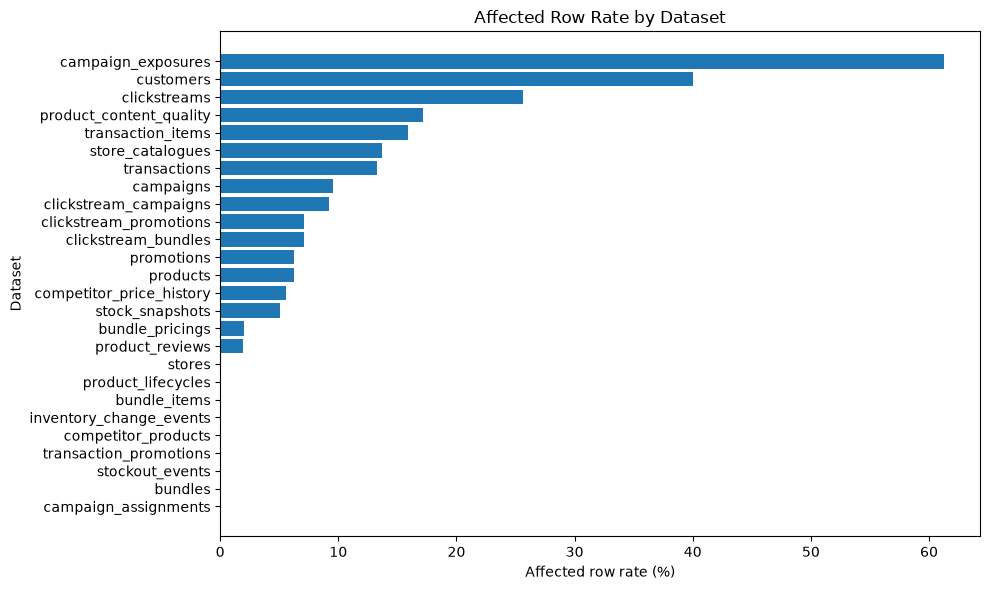

In [47]:
if not summary.empty:

    chart_data = (
        summary
        .sort_values(
            "affected_row_rate",
            ascending=True
        )
    )

    plt.figure(figsize=(10, 6))

    plt.barh(
        chart_data["dataset"],
        chart_data["affected_row_rate"]
    )

    plt.xlabel("Affected row rate (%)")
    plt.ylabel("Dataset")
    plt.title("Affected Row Rate by Dataset")

    plt.tight_layout()
    plt.show()

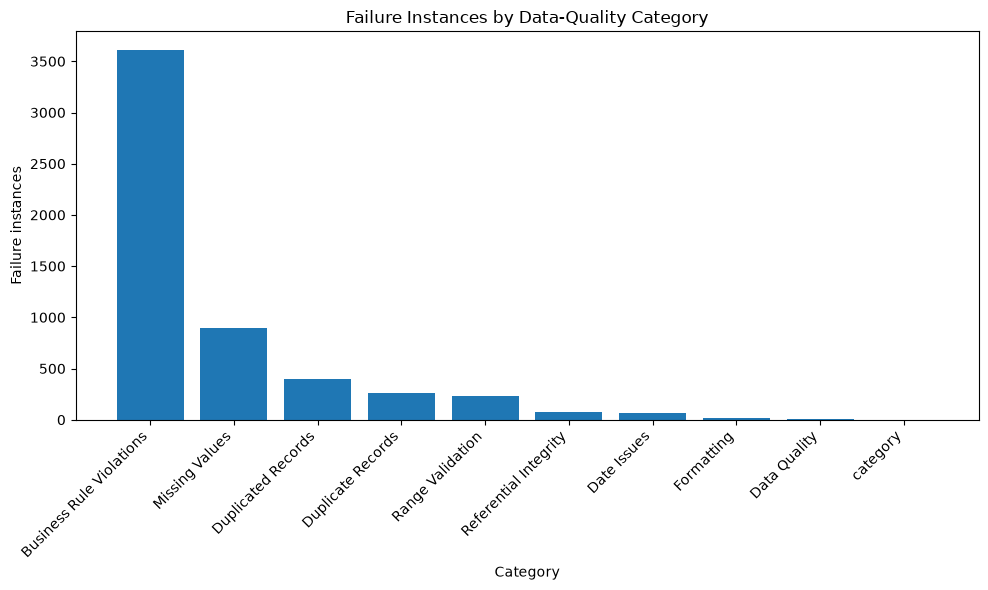

In [48]:
if not category_failures.empty:

    chart_data = (
        category_failures
        .groupby(
            "category",
            as_index=False
        )["failures"]
        .sum()
        .sort_values(
            "failures",
            ascending=False
        )
    )

    plt.figure(figsize=(10, 6))

    plt.bar(
        chart_data["category"],
        chart_data["failures"]
    )

    plt.xlabel("Category")
    plt.ylabel("Failure instances")
    plt.title("Failure Instances by Data-Quality Category")

    plt.xticks(
        rotation=45,
        ha="right"
    )

    plt.tight_layout()
    plt.show()

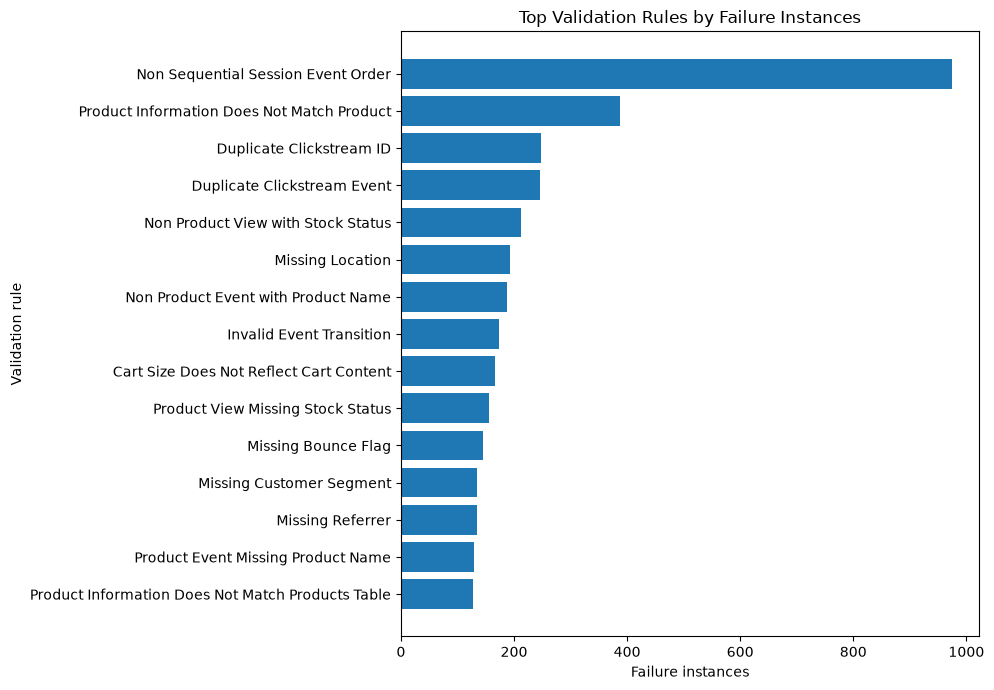

In [49]:
if not rule_failures.empty:

    chart_data = (
        rule_failures
        .groupby(
            "rule",
            as_index=False
        )["failures"]
        .sum()
        .sort_values(
            "failures",
            ascending=False
        )
        .head(15)
        .sort_values(
            "failures",
            ascending=True
        )
    )

    plt.figure(figsize=(10, 7))

    plt.barh(
        chart_data["rule"],
        chart_data["failures"]
    )

    plt.xlabel("Failure instances")
    plt.ylabel("Validation rule")
    plt.title("Top Validation Rules by Failure Instances")

    plt.tight_layout()
    plt.show()

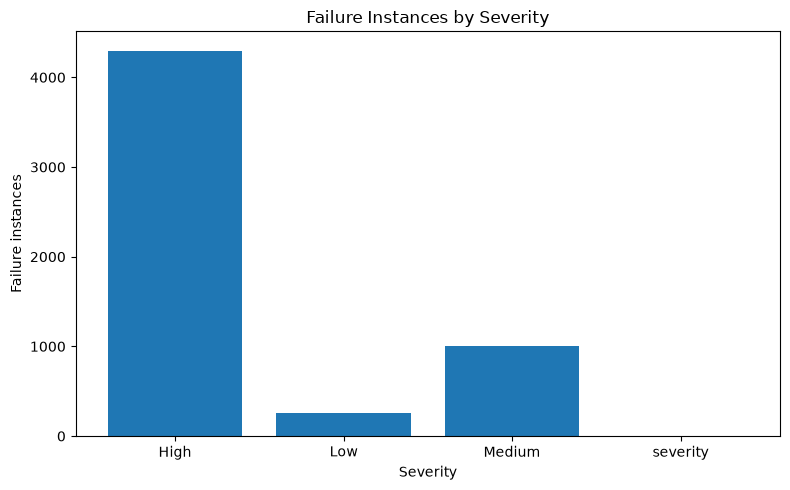

In [50]:
if not severity_failures.empty:

    chart_data = (
        severity_failures
        .groupby(
            "severity",
            as_index=False
        )["failures"]
        .sum()
    )

    plt.figure(figsize=(8, 5))

    plt.bar(
        chart_data["severity"],
        chart_data["failures"]
    )

    plt.xlabel("Severity")
    plt.ylabel("Failure instances")
    plt.title("Failure Instances by Severity")

    plt.tight_layout()
    plt.show()